## Data Exploration Notebook

### Big Data Assignment - Day 1

This notebook performs exploratory data analysis on the e-commerce dataset to understand:
- Data structure and quality
- Relationships between entities
- Potential data issues
- Statistical distributions

---

### Dataset Files
- `events.csv` - User behavior events 
- `messages.csv` - Campaign message tracking 
- `friends.csv` - Social network relationships 
- `client_first_purchase_date.csv` - Customer lifecycle 
- `campaigns.csv` - Campaign configuration 

---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define data paths
data_path = Path("../data/raw")
processed_path = Path("../data/processed")

# Ensure processed directory exists
processed_path.mkdir(parents=True, exist_ok=True)

print(f"Raw data path: {data_path}")
print(f"Processed data path: {processed_path}")

Raw data path: ..\data\raw
Processed data path: ..\data\processed


## Dataset Overview

Let's first examine the structure and size of each dataset

In [3]:
# Load and examine each dataset
datasets = {
    'events': 'events.csv',
    'messages': 'messages.csv', 
    'friends': 'friends.csv',
    'client_purchase': 'client_first_purchase_date.csv',
    'campaigns': 'campaigns.csv'
}

data_info = {}

for name, filename in datasets.items():
    file_path = data_path / filename
    
    # Get file size
    file_size_mb = file_path.stat().st_size / (1024 * 1024)
    
    # Load sample of data
    if name in ['events', 'messages']:  # Large files - sample first
        df_sample = pd.read_csv(file_path, nrows=1000)
        print(f"{name}: Loading sample (1000 rows)...")
    else:
        df_sample = pd.read_csv(file_path)
        print(f"{name}: Loading full dataset...")
    
    data_info[name] = {
        'filename': filename,
        'file_size_mb': file_size_mb,
        'columns': list(df_sample.columns),
        'dtypes': df_sample.dtypes.to_dict(),
        'sample_shape': df_sample.shape,
        'sample_data': df_sample.head()
    }
    
    print(f"   - File size: {file_size_mb:.1f} MB")
    print(f"   - Columns: {len(df_sample.columns)}")
    print(f"   - Sample shape: {df_sample.shape}")
    print()

events: Loading sample (1000 rows)...
   - File size: 166.2 MB
   - Columns: 9
   - Sample shape: (1000, 9)

messages: Loading sample (1000 rows)...
   - File size: 659.2 MB
   - Columns: 34
   - Sample shape: (1000, 34)

friends: Loading full dataset...
   - File size: 39.5 MB
   - Columns: 2
   - Sample shape: (1974237, 2)

client_purchase: Loading full dataset...
   - File size: 7.3 MB
   - Columns: 4
   - Sample shape: (174612, 4)

campaigns: Loading full dataset...
   - File size: 0.2 MB
   - Columns: 19
   - Sample shape: (1907, 19)



## Detailed Data Examination

Let's examine each dataset in detail to understand the data structure and identify potential issues

### 1. Events Dataset - User Behavior

In [4]:
# Examine events dataset
print("...EVENTS DATASET ANALYSIS...")

# Load sample
events_df = pd.read_csv(data_path / 'events.csv', nrows=10000)

print("\nSample Data:")
display(events_df.head())

print("\nColumn Information:")
for col in events_df.columns:
    print(f"- {col}: {events_df[col].dtype}")

print("\nBasic Statistics:")
print(events_df.describe())

print("\nEvent Types:")
print(events_df['event_type'].value_counts())

print("\nDate Range:")
events_df['event_time'] = pd.to_datetime(events_df['event_time'])
print(f"From: {events_df['event_time'].min()}")
print(f"To: {events_df['event_time'].max()}")

...EVENTS DATASET ANALYSIS...

Sample Data:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 02:28:19 UTC,view,1004434,2053013555631882655,electronics.smartphone,samsung,257.15,548844080,dcc9b83f-0332-4f04-8f3f-51ea311a5443
1,2019-10-01 02:39:53 UTC,view,1004449,2053013555631882655,electronics.smartphone,xiaomi,205.67,549110945,fbb8ecf9-3d1e-49d4-80bb-aec6ed2f0033
2,2019-10-01 02:49:08 UTC,view,1306798,2053013558920217191,computers.notebook,acer,332.05,555119848,7d8505d4-4756-4d60-8aa2-3938b752d8bc
3,2019-10-01 02:49:41 UTC,view,1306798,2053013558920217191,computers.notebook,acer,332.05,555119848,7d8505d4-4756-4d60-8aa2-3938b752d8bc
4,2019-10-01 02:59:27 UTC,view,5800778,2053013553945772349,electronics.audio.subwoofer,kicx,15.44,549040537,bc69321e-4aa0-45fc-b98e-9055032153fc



Column Information:
- event_time: object
- event_type: object
- product_id: int64
- category_id: int64
- category_code: object
- brand: object
- price: float64
- user_id: int64
- user_session: object

Basic Statistics:
         product_id   category_id         price       user_id
count  1.000000e+04  1.000000e+04  10000.000000  1.000000e+04
mean   9.495361e+06  2.055973e+18    319.243138  5.537097e+08
std    1.084265e+07  1.485371e+16    384.050202  3.480230e+06
min    1.002042e+06  2.053014e+18      0.000000  5.468061e+08
25%    1.004873e+06  2.053014e+18     76.700000  5.498666e+08
50%    4.000169e+06  2.053014e+18    179.670000  5.556220e+08
75%    1.562504e+07  2.053014e+18    385.940000  5.563716e+08
max    5.490001e+07  2.175420e+18   2574.040000  5.577896e+08

Event Types:
event_type
view        9541
cart         274
purchase     185
Name: count, dtype: int64

Date Range:
From: 2019-10-01 02:28:19+00:00
To: 2019-10-07 16:53:43+00:00


### 2. Campaigns Dataset - Marketing Configuration

In [6]:
# Examine campaigns dataset
print("...CAMPAIGNS DATASET ANALYSIS...")

campaigns_df = pd.read_csv(data_path / 'campaigns.csv')

print("\nSample Data:")
display(campaigns_df.head())

print("\nColumn Information:")
for col in campaigns_df.columns:
    print(f"- {col}: {campaigns_df[col].dtype}")

print("\nCampaign Types:")
print(campaigns_df['campaign_type'].value_counts())

print("\nChannels:")
print(campaigns_df['channel'].value_counts())

print("\nTopics:")
print(campaigns_df['topic'].value_counts().head(10))

...CAMPAIGNS DATASET ANALYSIS...

Sample Data:


,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
0,63,bulk,mobile_push,sale out,2021-04-30 07:22:36.615023,2021-04-30 07:23:41,48211.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
1,64,bulk,mobile_push,sale out,2021-04-30 09:02:50.817227,2021-04-30 09:04:08,1037337.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
2,78,bulk,mobile_push,sale out,2021-05-06 07:14:10.533318,2021-05-06 07:15:17,70080.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
3,79,bulk,mobile_push,sale out,2021-05-06 09:03:56.486750,2021-05-06 09:42:15,921838.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
4,89,bulk,mobile_push,NaN,2021-05-07 11:54:06.168664,2021-05-07 11:54:38,45503.0,NaN,False,NaN,109.0,False,True,True,False,False,False,NaN,NaN



Column Information:
- id: int64
- campaign_type: object
- channel: object
- topic: object
- started_at: object
- finished_at: object
- total_count: float64
- ab_test: object
- warmup_mode: object
- hour_limit: float64
- subject_length: float64
- subject_with_personalization: object
- subject_with_deadline: object
- subject_with_emoji: object
- subject_with_bonuses: object
- subject_with_discount: object
- subject_with_saleout: object
- is_test: object
- position: float64

Campaign Types:
campaign_type
bulk             1830
transactional      50
trigger            27
Name: count, dtype: int64

Channels:
channel
mobile_push     1396
email            483
multichannel      27
sms                1
Name: count, dtype: int64

Topics:
topic
sale out                  779
happy birthday            332
offer after purchase      316
leave review              287
event                      63
welcome campaign           27
order ready for pickup     10
order shipped              10
order created   

### 3. Messages Dataset - Campaign Delivery Tracking

In [17]:
# Examine messages dataset (sample due to size)
print("...MESSAGES DATASET ANALYSIS...")

messages_df = pd.read_csv(data_path / 'messages.csv', nrows=10000)

print("\nSample Data:")
display(messages_df.head())

print("\nColumn Information:")
for col in messages_df.columns:
    print(f"- {col}: {messages_df[col].dtype}")

print("\nMessage Types:")
print(messages_df['message_type'].value_counts())

print("\nChannels:")
print(messages_df['channel'].value_counts())

print("\nEngagement Metrics:")
engagement_cols = ['is_opened', 'is_clicked', 'is_purchased']
for col in engagement_cols:
    if col in messages_df.columns:
        print(f"- {col}: {messages_df[messages_df[col] == 't'].count()[col] / len(messages_df):.2%} rate")

...MESSAGES DATASET ANALYSIS...

Sample Data:


,id,message_id,campaign_id,message_type,client_id,channel,category,platform,email_provider,stream,date,sent_at,is_opened,opened_first_time_at,opened_last_time_at,is_clicked,clicked_first_time_at,clicked_last_time_at,is_unsubscribed,unsubscribed_at,is_hard_bounced,hard_bounced_at,is_soft_bounced,soft_bounced_at,is_complained,complained_at,is_blocked,blocked_at,is_purchased,purchased_at,created_at,updated_at,user_device_id,user_id
0,3533908,b7d6772d-8989-4abe-b14f-da8935fb7482,179,transactional,1515915625487629506,email,NaN,NaN,mail.ru,desktop,2021-04-30,2021-04-30 07:40:30,t,2021-05-13 05:25:42,2021-05-13 05:25:42,f,NaN,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,2023-04-27 08:55:15.526907,2023-04-27 09:00:45.678375,6,548762950
1,3520988,05f889ef-98ed-4eee-acb6-de4f30be4837,27,transactional,1515915625594602211,email,NaN,NaN,mail.ru,desktop,2021-04-30,2021-04-30 13:05:57,t,2021-05-01 05:20:26,2021-05-01 05:20:26,f,NaN,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,2023-04-27 08:54:56.567977,2023-04-27 08:55:18.969367,1,559460221
2,3521097,0ce3deaf-1773-46ed-88a9-90ea1dcb1fdc,27,transactional,1515915625505234697,email,NaN,NaN,gmail.com,desktop,2021-04-30,2021-04-30 11:24:51,f,NaN,NaN,f,NaN,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,2023-04-27 08:54:56.768951,2023-04-27 08:54:56.769921,7,550523469
3,3521249,1692346e-2c6d-427d-9b08-d10cf081a561,27,transactional,1515915625472683606,email,NaN,NaN,gmail.com,desktop,2021-04-30,2021-04-30 08:15:58,t,2021-04-30 08:25:28,2021-04-30 08:25:28,f,NaN,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,2023-04-27 08:54:56.993038,2023-04-27 08:54:56.99424,6,547268360
4,3521284,18f7050c-96a4-4f68-921d-1dbbd7929f5a,27,transactional,1515915625500988431,email,NaN,NaN,yandex.ru,desktop,2021-04-30,2021-04-30 23:22:52,t,2021-05-01 19:46:33,2021-05-01 19:46:33,f,NaN,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,2023-04-27 08:54:57.045129,2023-04-27 08:55:19.296068,1,550098843



Column Information:
- id: int64
- message_id: object
- campaign_id: int64
- message_type: object
- client_id: int64
- channel: object
- category: float64
- platform: object
- email_provider: object
- stream: object
- date: object
- sent_at: object
- is_opened: object
- opened_first_time_at: object
- opened_last_time_at: object
- is_clicked: object
- clicked_first_time_at: object
- clicked_last_time_at: object
- is_unsubscribed: object
- unsubscribed_at: object
- is_hard_bounced: object
- hard_bounced_at: object
- is_soft_bounced: object
- soft_bounced_at: object
- is_complained: object
- complained_at: object
- is_blocked: object
- blocked_at: float64
- is_purchased: object
- purchased_at: object
- created_at: object
- updated_at: object
- user_device_id: int64
- user_id: int64

Message Types:
message_type
bulk             7356
trigger          2215
transactional     429
Name: count, dtype: int64

Channels:
channel
mobile_push    7356
email          2644
Name: count, dtype: int64

Eng

In [11]:
for col in messages_df.columns:
    if 'is_' in col:
        print(f"- {col}: {messages_df[col].dtype}")
        print(messages_df[col].value_counts())
        print()
        

- is_opened: object
is_opened
f    8120
t    1880
Name: count, dtype: int64

- is_clicked: object
is_clicked
f    9875
t     125
Name: count, dtype: int64

- is_unsubscribed: object
is_unsubscribed
f    9606
t     394
Name: count, dtype: int64

- is_hard_bounced: object
is_hard_bounced
f    9981
t      19
Name: count, dtype: int64

- is_soft_bounced: object
is_soft_bounced
f    9999
t       1
Name: count, dtype: int64

- is_complained: object
is_complained
f    9997
t       3
Name: count, dtype: int64

- is_blocked: object
is_blocked
f    10000
Name: count, dtype: int64

- is_purchased: object
is_purchased
f    9996
t       4
Name: count, dtype: int64



### 4. Friends Dataset - Social Network

In [19]:
# Examine friends dataset
print("...FRIENDS DATASET ANALYSIS...")

friends_df = pd.read_csv(data_path / 'friends.csv', nrows=10000)

print("\nSample Data:")
display(friends_df.head())

print("\nColumn Information:")
for col in friends_df.columns:
    print(f"- {col}: {friends_df[col].dtype}")

print("\nStatistics:")
print(f"Total friendships: {len(friends_df)}")
print(f"Unique users: {friends_df['friend1'].nunique()}")
print(f"Unique friends: {friends_df['friend2'].nunique()}")

# Check for mutual friendships
print("\nMutual Friendship Check:")
# Create a set for quick lookup
friend_pairs = set(zip(friends_df['friend1'], friends_df['friend2']))
mutual_count = sum(1 for friend1, friend2 in friend_pairs 
                  if (friend2, friend1) in friend_pairs)
print(f"Mutual friendships: {mutual_count} ({mutual_count/len(friends_df):.2%})")

...FRIENDS DATASET ANALYSIS...

Sample Data:


,friend1,friend2
0,554816768,556499463
1,554764232,563685774
2,563852395,548848705
3,548930365,556076968
4,562908521,555239748



Column Information:
- friend1: int64
- friend2: int64

Statistics:
Total friendships: 10000
Unique users: 9919
Unique friends: 9934

Mutual Friendship Check:
Mutual friendships: 0 (0.00%)


### 5. Client First Purchase Dataset - Customer Lifecycle

In [20]:
# Examine client first purchase dataset
print("...CLIENT FIRST PURCHASE DATASET ANALYSIS...")

client_df = pd.read_csv(data_path / 'client_first_purchase_date.csv')

print("\nSample Data:")
display(client_df.head())

print("\nColumn Information:")
for col in client_df.columns:
    print(f"- {col}: {client_df[col].dtype}")

print("\nStatistics:")
print(f"Total clients: {len(client_df)}")
print(f"Unique clients: {client_df['client_id'].nunique()}")

# Parse dates
client_df['first_purchase_date'] = pd.to_datetime(client_df['first_purchase_date'])
print("\nPurchase Date Range:")
print(f"From: {client_df['first_purchase_date'].min()}")
print(f"To: {client_df['first_purchase_date'].max()}")

# Extract user_id from client_id (151591562 + user_id + device_id)
print("\nClient ID Structure Analysis:")
sample_client_ids = client_df['client_id'].head(10).tolist()
for client_id in sample_client_ids:
    print(f"Client ID: {client_id}")
    if isinstance(client_id, str) and client_id.startswith('151591562'):
        remaining = client_id[9:]  # Remove prefix
        print(f"  After prefix: {remaining}")
        if '_' in remaining:
            user_part, device_part = remaining.split('_', 1)
            print(f"  User part: {user_part}")
            print(f"  Device part: {device_part}")
    print()

...CLIENT FIRST PURCHASE DATASET ANALYSIS...

Sample Data:


,client_id,first_purchase_date,user_id,user_device_id
0,1515915625488560902,2023-11-12,548856090,2
1,1515915625468115567,2022-01-04,546811556,7
2,1515915625629342539,2023-12-01,562934253,9
3,1515915625490630727,2023-11-07,549063072,7
4,1515915625490111817,2022-01-11,549011181,7



Column Information:
- client_id: int64
- first_purchase_date: object
- user_id: int64
- user_device_id: int64

Statistics:
Total clients: 174612
Unique clients: 174612

Purchase Date Range:
From: 2021-12-15 00:00:00
To: 2023-12-14 00:00:00

Client ID Structure Analysis:
Client ID: 1515915625488560902

Client ID: 1515915625468115567

Client ID: 1515915625629342539

Client ID: 1515915625490630727

Client ID: 1515915625490111817

Client ID: 1515915625613583764

Client ID: 1515915625626966047

Client ID: 1515915625500897119

Client ID: 1515915625490586749

Client ID: 1515915625491237185



## Data Quality Assessment

Now let's check for data quality issues across all datasets

In [23]:
def check_data_quality(df, name):
    """Check data quality issues"""
    print(f"\n...{name.upper()} DATA QUALITY CHECK...")
    
    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("Missing Values:")
        for col, count in missing[missing > 0].items():
            print(f"  - {col}: {count} ({count/len(df):.2%})")
    else:
        print("No missing values found")
    
    # Duplicates
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Duplicates: {duplicates} ({duplicates/len(df):.2%})")
    else:
        print("No duplicates found")
    
    # Data types
    print("Data Types:")
    for col, dtype in df.dtypes.items():
        print(f"  - {col}: {dtype}")

# Check quality for each dataset
check_data_quality(events_df, 'Events')
check_data_quality(campaigns_df, 'Campaigns')
check_data_quality(messages_df, 'Messages')
check_data_quality(friends_df, 'Friends')
check_data_quality(client_df, 'Client Purchase')


...EVENTS DATA QUALITY CHECK...
Missing Values:
  - category_code: 2892 (28.92%)
  - brand: 1250 (12.50%)
No duplicates found
Data Types:
  - event_time: datetime64[ns, UTC]
  - event_type: object
  - product_id: int64
  - category_id: int64
  - category_code: object
  - brand: object
  - price: float64
  - user_id: int64
  - user_session: object

...CAMPAIGNS DATA QUALITY CHECK...
Missing Values:
  - topic: 30 (1.57%)
  - started_at: 83 (4.35%)
  - finished_at: 99 (5.19%)
  - total_count: 83 (4.35%)
  - ab_test: 1895 (99.37%)
  - warmup_mode: 77 (4.04%)
  - hour_limit: 1876 (98.37%)
  - subject_length: 27 (1.42%)
  - subject_with_personalization: 27 (1.42%)
  - subject_with_deadline: 27 (1.42%)
  - subject_with_emoji: 27 (1.42%)
  - subject_with_bonuses: 27 (1.42%)
  - subject_with_discount: 27 (1.42%)
  - subject_with_saleout: 27 (1.42%)
  - is_test: 1880 (98.58%)
  - position: 1883 (98.74%)
No duplicates found
Data Types:
  - id: int64
  - campaign_type: object
  - channel: object


## Visual Analysis

Let's create some visualizations to better understand the data distributions

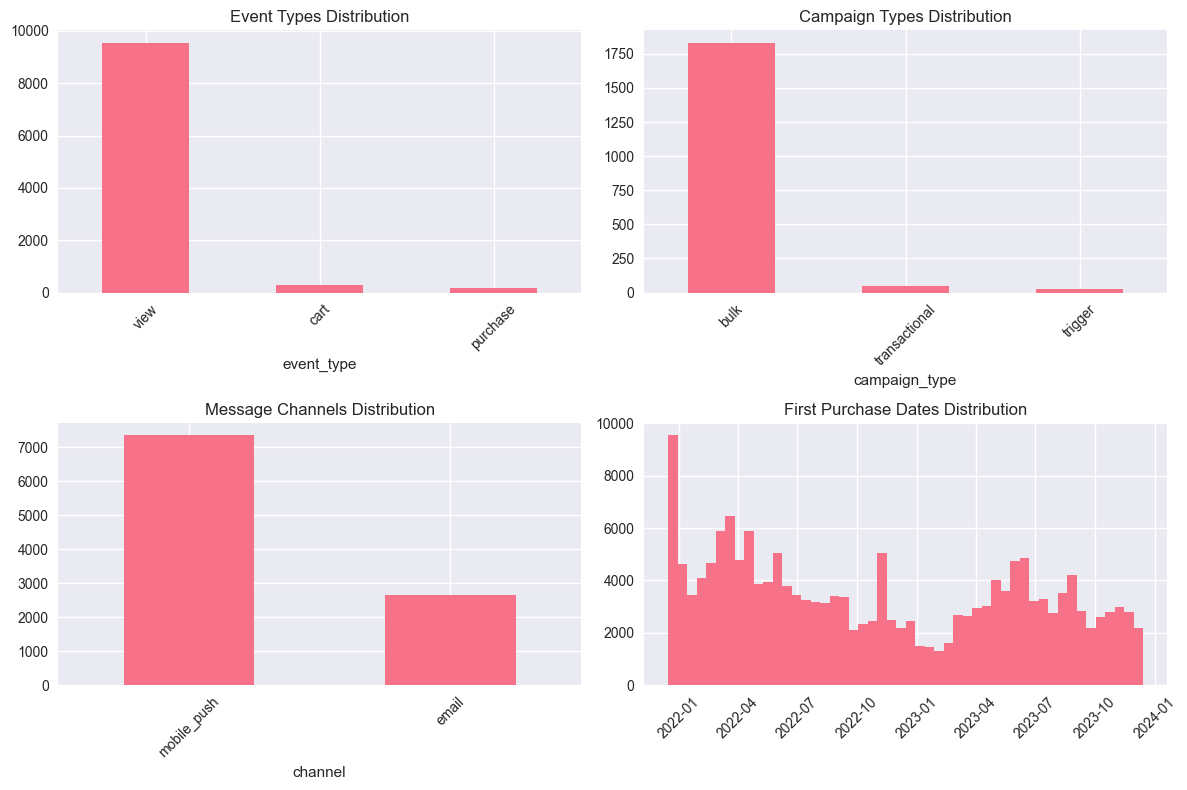

In [24]:
# Event type distribution
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
events_df['event_type'].value_counts().plot(kind='bar')
plt.title('Event Types Distribution')
plt.xticks(rotation=45)

# Campaign types
plt.subplot(2, 2, 2)
campaigns_df['campaign_type'].value_counts().plot(kind='bar')
plt.title('Campaign Types Distribution')
plt.xticks(rotation=45)

# Message channels
plt.subplot(2, 2, 3)
messages_df['channel'].value_counts().plot(kind='bar')
plt.title('Message Channels Distribution')
plt.xticks(rotation=45)

# Purchase dates over time
plt.subplot(2, 2, 4)
client_df['first_purchase_date'].hist(bins=50)
plt.title('First Purchase Dates Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Data Relationships Analysis

Let's examine how the datasets connect to each other

In [26]:
# Check user overlap between datasets
print("...DATA RELATIONSHIP ANALYSIS...")

# Users in events
events_users = set(events_df['user_id'].unique())
print(f"Users in events: {len(events_users):,}")

# Users in friends
friends_users = set(friends_df['friend1'].unique()) | set(friends_df['friend2'].unique())
print(f"Users in friends: {len(friends_users):,}")

# Campaign overlap
campaign_ids = set(campaigns_df['id'].unique())
message_campaigns = set(messages_df['campaign_id'].unique())
print(f"Campaigns in campaigns table: {len(campaign_ids):,}")
print(f"Campaigns in messages table: {len(message_campaigns):,}")
print(f"Campaign overlap: {len(campaign_ids & message_campaigns):,}")

# Product analysis
products_in_events = set(events_df['product_id'].unique())
print(f"Products in events: {len(products_in_events):,}")
print(f"Unique categories: {events_df['category_id'].nunique():,}")
print(f"Unique brands: {events_df['brand'].nunique():,}")

...DATA RELATIONSHIP ANALYSIS...
Users in events: 1,572
Users in friends: 19,687
Campaigns in campaigns table: 1,900
Campaigns in messages table: 20
Campaign overlap: 20
Products in events: 3,649
Unique categories: 339
Unique brands: 610
